<a href="https://colab.research.google.com/github/Astro111000/Electropreorg_theozymes_rfd3/blob/main/Preorganization_in_RFD3_scaffolds_with_PLACER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Remember to connect to GPU runtime on colab before running PLACER.

# Actual work from below

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [ ]:
import shutil
from google.colab import files

def download(folder_name, folder_path):

  # 1. Define the folder you want to zip and the desired output zip file path
  folder_to_download = folder_path
  output_zip_file = f'/content/{folder_name}.zip'

  # 2. Compress the directory
  # Note: make_archive automatically appends '.zip', so we strip it from the output string here
  shutil.make_archive(output_zip_file.replace('.zip', ''), 'zip', folder_to_download)
  print(f"Successfully zipped {folder_to_download} into {output_zip_file}")

  # 3. Trigger the browser download
  files.download(output_zip_file)

## PLACER download

In [ ]:
!git clone https://github.com/baker-laboratory/PLACER.git

Cloning into 'PLACER'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 120 (delta 14), reused 14 (delta 14), pack-reused 88 (from 1)
Receiving objects: 100% (120/120), 93.23 MiB | 34.88 MiB/s, done.
Resolving deltas: 100% (40/40), done.


The below takes 10 min

In [ ]:
!conda env create -f /content/PLACER/envs/placer_env.yml

Streaming output truncated to the last 5000 lines.
libnpp-static-12.1.0 | 91.2 MB   | :  12% 0.1176452143606369/1 [00:41<00:05,  5.78s/it] 
















pytorch-2.3.1        | 1.37 GB   | :  72% 0.718219280142144/1 [00:41<01:06, 235.26s/it] 

















qt6-main-6.8.1       | 48.8 MB   | :  28% 0.2780462736194111/1 [00:41<00:02,  2.83s/it] 















libnpp-static-12.1.0 | 91.2 MB   | :  15% 0.1474418188711912/1 [00:41<00:04,  4.79s/it]
















pytorch-2.3.1        | 1.37 GB   | :  72% 0.7196736597516571/1 [00:41<00:54, 195.13s/it]

















qt6-main-6.8.1       | 48.8 MB   | :  32% 0.31776716985075554/1 [00:41<00:01,  2.74s/it]















libnpp-static-12.1.0 | 91.2 MB   | :  18% 0.17740966823525448/1 [00:41<00:03,  4.25s/it]
















pytorch-2.3.1        | 1.37 GB   | :  72% 0.7221938442658515/1 [00:41<00:37, 136.73s/it]

















qt6-main-6.8.1       | 48.8 MB   | :  39% 0.3879193978722429/1 [00:42<00:01,  2.18s/it] 















libnp

## Clustering and analysis of PLACER ensembles using cpptraj (due to its ease of use)

For this, we will be downloading and using AmberTools (https://ambermd.org/GetAmber.php) and using the instructions provided by them. This is required for cpptraj analysis, which is what we will be using for clustering, since it seems relatively strightforward and standardized

REMEMBER TO SWITCH TO CPU, AFTER YOU DOWNLOADED THE OUTPUT FROM PLACER ABOVE

In [ ]:
!conda create --name ambert python=3.12

Channels:
 - conda-forge
Platform: linux-64
Solving environment: \ | done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/ambert

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    icu-78.2                   |       h33c6efd_0        12.1 MB  conda-forge
    ld_impl_linux-64-2.45.1    |default_hbd61a6d_101         709 KB  conda-forge
    libexpat-2.7.4             |       hecca717_0          75 KB  conda-forge
  

In [ ]:
!conda activate ambert
!conda config --add channels conda-forge
!conda config --set channel_priority strict
!conda install --name ambert dacase::ambertools-dac=25


CondaError: Run 'conda init' before 'conda activate'

Channels:
 - conda-forge
 - dacase
Platform: linux-64
Solving environment: | / - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/ambert

  added / updated specs:
    - dacase::ambertools-dac=25


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ambertools-dac-25.3.0      |  py312h2009f2f_0       565.2 MB  dacase
    arpack-3.9.1               |nompi_hf03ea27_102         127 KB  conda-forge
    attr-2.5.2                 |       h39aace5_0          66 KB  conda-forge
    backports.zstd-1.3.0       |  py312h90b7ffd_0         232 KB  conda-forge
    blosc-1.21.6               |       he440d0b_1          47 KB  conda-forge


In [ ]:
%cd /content

/content


In [ ]:
%%writefile test_cpptraj.in

parm /content/1lar-nowater.parm7
trajin /content/1lar-nowater-run1.nc.1 1 last 10
trajin /content/1lar-nowater-run2.nc 1 last 10
trajin /content/1lar-nowater-run3.nc 1 last 10
strip :Na+,Cl-
cluster c1 \
  hieragglo epsilon 3.0 clusters 10 averagelinkage \
  rms :1-576@C,N,O,CA,CB&!@H= \
  sieve 10 random \
  out cnumvtime.dat \
  summary summary.dat \
  info info.dat \
  cpopvtime cpopvtime.agr normframe \
  repout rep repfmt pdb \
  singlerepout singlerep.pdb singlerepfmt pdb \
  avgout avg avgfmt pdb
run

Overwriting test_cpptraj.in


In [ ]:
%%bash

source /usr/local/envs/ambert/amber.sh

#Note that this only works when all these are in the same cell. So I suppose when I run ambertools, I have reinitialize AMBERHOME env_varibale
echo "AMBERHOME is successfully set to: $AMBERHOME"

cd $AMBERHOME/second_output

cpptraj -i /content/test_cpptraj.in

AMBERHOME is successfully set to: /usr/local/envs/ambert

CPPTRAJ: Trajectory Analysis. V6.29.13 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 03/14/26 16:13:02
| Available memory: 5.583 GB

INPUT: Reading input from '/content/test_cpptraj.in'
  [parm /content/1lar-nowater.parm7]
	Reading '/content/1lar-nowater.parm7' as Amber Topology
	Radius Set: modified Bondi radii (mbondi)
  [trajin /content/1lar-nowater-run1.nc.1 1 last 10]
	Reading '/content/1lar-nowater-run1.nc.1' as Amber NetCDF
  [trajin /content/1lar-nowater-run2.nc 1 last 10]
	Reading '/content/1lar-nowater-run2.nc' as Amber NetCDF
  [trajin /content/1lar-nowater-run3.nc 1 last 10]
	Reading '/content/1lar-nowater-run3.nc' as Amber NetCDF
  [strip :Na+,Cl-]
    STRIP: Stripping atoms in mask [:Na+,Cl-]
  [cluster c1 hieragglo epsilon 3.0 clusters 10 averagelinkage rms :1-576@C,N,O,CA,CB&!@H= sieve 10 random out cnumvtime.dat summary summary.dat info info.dat cpopvtime cpopvti

The original Baker lab paper using RFD and PLACER (https://pmc.ncbi.nlm.nih.gov/articles/PMC12288761/#S4) figure out the freqeuncy of catalytically competent conformations based on distance metrics for hydrogen bonds. CLustering can't neccesarily distinguish between catalytically competant and catalytically incompitant poses (since catalytic competence fuiltering is not exactly dtermined based on RMSD, which is what is used for clustering). So, clustering actually gives us information over catalytically unfavoruable conformations, which we can filter out using engineering.

Now lets try the actual test ensemble

In [ ]:
%%writefile ensemble_test_cpptraj.in

parm /content/reference_topology.pdb
trajin /content/ensemble_trajectory.dcd 1 last
strip :Na+,Cl-
cluster c1 \
  hieragglo epsilon 0.1 averagelinkage \
  rms :67,51&!@H= \
  out cnumvtime.dat \
  summary summary_ensemble.dat \
  info info.dat \
  cpopvtime cpopvtime.agr normframe \
  repout rep repfmt pdb \
  singlerepout singlerep.nc singlerepfmt netcdf \
  avgout avg avgfmt pdb
run

Overwriting ensemble_test_cpptraj.in


In [ ]:
%%bash

source /usr/local/envs/ambert/amber.sh

#Note that this only works when all these are in the same cell. So I suppose when I run ambertools, I have reinitialize AMBERHOME env_varibale
echo "AMBERHOME is successfully set to: $AMBERHOME"

mkdir $AMBERHOME/ensemble_test_2
cd $AMBERHOME/ensemble_test_2

cpptraj -i /content/ensemble_test_cpptraj.in

AMBERHOME is successfully set to: /usr/local/envs/ambert

CPPTRAJ: Trajectory Analysis. V6.29.13 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 03/15/26 14:27:59
| Available memory: 7.812 GB

INPUT: Reading input from '/content/ensemble_test_cpptraj.in'
  [parm /content/reference_topology.pdb]
	Reading '/content/reference_topology.pdb' as PDB File
	Reading bond info from CONECT records.
	Not reading bond info from LINK records.
	Determining bond info from distances.
  [trajin /content/ensemble_trajectory.dcd 1 last]
	Reading '/content/ensemble_trajectory.dcd' as Charmm DCD
	NAMD unit cell detected.
  [strip :Na+,Cl-]
    STRIP: Stripping atoms in mask [:Na+,Cl-]
  [cluster c1 hieragglo epsilon 0.1 averagelinkage rms :67,51&!@H= out cnumvtime.dat summary summary_ensemble.dat info info.dat cpopvtime cpopvtime.agr normframe repout rep repfmt pdb singlerepout singlerep.nc singlerepfmt netcdf avgout avg avgfmt pdb]
	Using Manhattan distance.


In our study, we will be studying preorgaization of RFD2 generated structures and ALSO figure out what makes some non-productive poses to be poplated. Therefore, our control groups should be able to find both answers for already tested proteins -- How much preorganization and making clear why some clusters are not preorganized.


We will hence select HG3 and HG3.17 for -ve and +ve control, respectively.

HG3 is a pre directed evolution Kemp eliminase that has been experimentally shown to occupy non-preorganized states. The lack of preorganization is due to the obstrucution of an NCI by M84, which is required for proper orientation of catlytic base D127, and a non-productive NCI of the oxyanion stabalizer K50, which prevents it from doing it's job. We do expect to see this in the PLACER ensembles for HG3

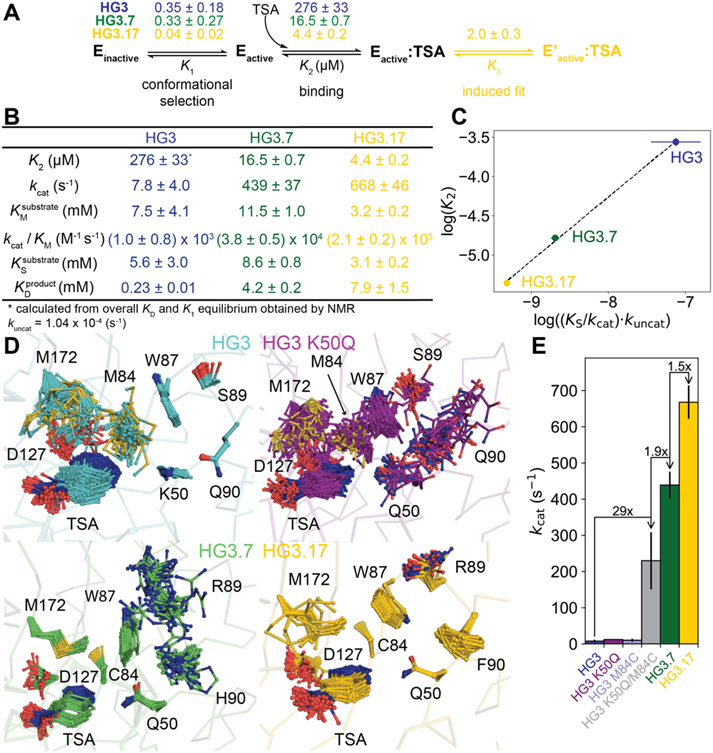

In [ ]:
#@markdown Fig. 4. Transition-state analogue binding as a proxy for probing the chemical activation barrier over evolution. From https://pmc.ncbi.nlm.nih.gov/articles/PMC9616100

!wget https://cdn.ncbi.nlm.nih.gov/pmc/blobs/2f1a/9616100/8b3c3b02f4e2/nihms-1842694-f0004.jpg >/dev/null 2>&1

from IPython.display import Image
Image(filename="/content/nihms-1842694-f0004.jpg")

Therefore, for the -ve control, we will be doing the following (note all main steps are normal while all technical/computational steps are in italics):


1. Obtain the PLACER ensemble for HG3's active site, maybe 50/100 ensembles

2. *Convert the multi-modal PDB file into a topology and trajectory file for ease of analysis with cpptraj*

3. Define catalytically competant interactions in terms of distances and angles (like H-bonding between active site residues), and use MDAnalysis to filter out "frames" that satisfy these criteria.
- This should give us inofmration along the lines of "Among 100 ensemble strucutres, x% were catalytically competent". The expected trend is that more preorganized structures will have a higher x% than non-preorganized structures.

4. Perform clustering analsyis on the 100 ensemble strucutres to figure out what are the catalytically non-productive populations, and how often do they show up.
- This should be useful in not only seeing the non-productive conformations, but also give an idea of which residues are leading to poor preorganization and hence which residues need to be mutated.

- In a way, we should be able to predict what mutations should be done to HG3 so that it can be moire active, and compare that logic's result with HG3.17. This would just further validate the protocol of using both freqeuncy and clustering analysis for preorganization.

## PLACER ensemble of HG3

In [ ]:
%%writefile hg3_10_rotamer_ensemble.py

import sys, os
import warnings
warnings.filterwarnings("ignore")
import json
import pandas as pd
import matplotlib.pyplot as plt

from PLACER import PLACER
placer = PLACER.PLACER()

print("Trying to predict the ensemble strucutre of HG3 apo active site")

ciffile = "/content/7K4Q_A.cif"
ODIR = "/content/75_hg3_placer_croped_final_2"

pl_inp = PLACER.PLACERinput()
pl_inp.cif(ciffile)
pl_inp.exclude_sm(True) #the function of this is to exclude the ligand during ensemble prediction (view https://github.com/baker-laboratory/PLACER/blob/main/modules/placer_input.py)
pl_inp.name(os.path.basename(ciffile).replace(".cif", ""))

#pl_inp.target_res(target_res=('A', 127))
pl_inp.crop_centers(points=[(-5.881, 27.754, 0.174)]) #THIS IS REQUIRED!!!!
#-5.881 27.754 0.174 -- coordinates of the atom above
#'A', 127, 'ASP', 'OD2'
#Don't overthink and use the above 2, they lead to inaccurate results

hg3_ensemble = placer.run(pl_inp, 75)

os.makedirs(ODIR, exist_ok=True)
print(f"Writing outputs to {ODIR}")
PLACER.protocol.dump_output(hg3_ensemble, f"{ODIR}/{pl_inp.name()}", rerank="prmsd")

df = pd.DataFrame.from_dict({k: [hg3_ensemble[n][k] for n in hg3_ensemble] for k in hg3_ensemble[0].keys() if k not in ["item", "model"]})


Overwriting hg3_10_rotamer_ensemble.py


In [ ]:
!mamba run -n placer_env python hg3_10_rotamer_ensemble.py

# device:  cuda:0
Using checkpoint: /content/PLACER/weights/PLACER_model_1.pt
# variables:  5071802
Trying to predict the ensemble strucutre of HG3 apo active site
Keeping these ligands fixed during prediction IF they are in the crop: [].
--> 0 7K4Q_A {ID:type/atoms/bonds} : {A:polypeptide(L)/4660/4711; C:nonpoly/16/17; D:nonpoly/5/4}
model    1 :  fape= 1.24864  lddt= 0.96430  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.89481  plddt= 0.96979  plddt_pde= 0.93102  | time= 5.41s  mem= 3.04gb 
model    2 :  fape= 1.45430  lddt= 0.95519  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.96610  plddt= 0.95950  plddt_pde= 0.92678  | time= 3.93s  mem= 3.17gb 
model    3 :  fape= 1.44747  lddt= 0.94860  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.91579  plddt= 0.96657  plddt_pde= 0.93228  | time= 4.04s  mem= 3.17gb 
model    4 :  fape= 1.78230  lddt= 0.93178  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.95897  plddt= 0.96232  plddt_pde= 0.92735  | time= 3.93s  mem= 3.17gb 
model    5 :  fape= 1.52616  lddt= 0.94

In [ ]:
%%writefile hg3_10_rotamer_bound_ligand.py

import sys, os
import warnings
warnings.filterwarnings("ignore")
import json
import pandas as pd
import matplotlib.pyplot as plt

from PLACER import PLACER
placer = PLACER.PLACER()

print("Trying to predict the ensemble strucutre of HG3 active site (how the heck does PLACER know where the active site is?????)")

ciffile = "/content/7K4Q_A.cif"
ODIR = "/content/10_hg3_placer_proper_holo_test_mol2"

pl_inp = PLACER.PLACERinput()
pl_inp.cif(ciffile)
pl_inp.exclude_sm(False) #the function of this is to exclude the ligand during ensemble prediction (view https://github.com/baker-laboratory/PLACER/blob/main/modules/placer_input.py)
pl_inp.ligand_reference({'6NT':'/content/6NT_ideal_mol2.mol2'})
pl_inp.name(os.path.basename(ciffile).replace(".cif", ""))

#pl_inp.target_res(target_res=('A', 127))
pl_inp.crop_centers(points=[('A', 127, 'ASP', 'OD2'), ('A', 401, '6NT', 'N2'), (-5.395,29.209,1.824)])

#Don't overthink and use the above 2, they lead to inaccurate results

hg3_ensemble = placer.run(pl_inp, 75) #we will keep it 10 for now just to understand if this is working

os.makedirs(ODIR, exist_ok=True)
print(f"Writing outputs to {ODIR}")
PLACER.protocol.dump_output(hg3_ensemble, f"{ODIR}/{pl_inp.name()}", rerank="prmsd")

df = pd.DataFrame.from_dict({k: [hg3_ensemble[n][k] for n in hg3_ensemble] for k in hg3_ensemble[0].keys() if k not in ["item", "model"]})


Overwriting hg3_10_rotamer_bound_ligand.py


In [ ]:
!mamba run -n placer_env python hg3_10_rotamer_bound_ligand.py

# device:  cuda:0
Using checkpoint: /content/PLACER/weights/PLACER_model_1.pt
# variables:  5071802
Trying to predict the ensemble strucutre of HG3 active site (how the heck does PLACER know where the active site is?????)
Reading ligand 6NT reference definition from file: /content/6NT_ideal_mol2.mol2
Keeping these ligands fixed during prediction IF they are in the crop: [].
--> 0 7K4Q_A {ID:type/atoms/bonds} : {A:polypeptide(L)/4660/4711; C:nonpoly/16/17; D:nonpoly/5/4}
model    1 :  fape= 1.71244  lddt= 0.93727  rmsd= 2.03656  kabsch= 0.15517  prmsd= 3.32923  plddt= 0.69833  plddt_pde= 0.72077  | time= 5.45s  mem= 3.12gb 
model    2 :  fape= 1.59759  lddt= 0.91725  rmsd= 4.61752  kabsch= 0.74622  prmsd= 3.09784  plddt= 0.74500  plddt_pde= 0.73576  | time= 3.96s  mem= 3.26gb 
model    3 :  fape= 1.34863  lddt= 0.96366  rmsd= 1.63717  kabsch= 0.04925  prmsd= 0.94401  plddt= 0.99000  plddt_pde= 0.85342  | time= 3.93s  mem= 3.26gb 
model    4 :  fape= 1.57924  lddt= 0.93776  rmsd= 2.90000

The ligand still is not properly denoised, even with a reference structure provided. So, we might have to work with apo structures, for now

### Analysing the 75 apo ensemble with cpptraj clustering

In [ ]:
!pip install MDAnalysis

import numpy as np

import MDAnalysis as mda
from MDAnalysis.analysis import pca, align

import warnings
# suppress some MDAnalysis warnings about writing PDB files
warnings.filterwarnings('ignore')

In [ ]:
pdb_file="/content/75_hg3_placer_croped_final_2.pdb"
ensemble=mda.Universe(pdb_file)

print(len(ensemble.trajectory[1]))

print(ensemble.trajectory)

u=ensemble

# 2. Extract and save the FIRST frame as your default PDB topology
topology_out = "hg3_croped_apo_topology.pdb"
u.trajectory[0]  # Explicitly set the universe to the first frame
u.atoms.write(topology_out)
print(f"Saved the first frame as the topology file: {topology_out}")

# 3. Convert and write the entire ensemble into a .dcd trajectory file
trajectory_out = "hg3_croped_apo_ensemble_trajectory.dcd"

# Open an MDAnalysis Writer for the .dcd format
with mda.Writer(trajectory_out, u.atoms.n_atoms) as W:
    # Loop through every frame in the loaded multi-model PDB
    for model in u.trajectory:
        W.write(u.atoms)

583
<PDBReader /content/75_hg3_placer_croped_final_2.pdb with 75 frames of 583 atoms>
Saved the first frame as the topology file: hg3_croped_apo_topology.pdb


In [ ]:
for i, residue in enumerate(ensemble.residues, start=1):
    print(f"cpptraj index: {i} | PDB Info: {residue}")

cpptraj index: 1 | PDB Info: <Residue TYR, 22>
cpptraj index: 2 | PDB Info: <Residue GLY, 24>
cpptraj index: 3 | PDB Info: <Residue VAL, 25>
cpptraj index: 4 | PDB Info: <Residue ALA, 26>
cpptraj index: 5 | PDB Info: <Residue THR, 27>
cpptraj index: 6 | PDB Info: <Residue ASP, 28>
cpptraj index: 7 | PDB Info: <Residue MET, 47>
cpptraj index: 8 | PDB Info: <Residue VAL, 48>
cpptraj index: 9 | PDB Info: <Residue TRP, 49>
cpptraj index: 10 | PDB Info: <Residue PRO, 50>
cpptraj index: 11 | PDB Info: <Residue GLU, 51>
cpptraj index: 12 | PDB Info: <Residue ASN, 52>
cpptraj index: 13 | PDB Info: <Residue SER, 53>
cpptraj index: 14 | PDB Info: <Residue MET, 54>
cpptraj index: 15 | PDB Info: <Residue LYS, 55>
cpptraj index: 16 | PDB Info: <Residue TRP, 56>
cpptraj index: 17 | PDB Info: <Residue LEU, 74>
cpptraj index: 18 | PDB Info: <Residue LEU, 84>
cpptraj index: 19 | PDB Info: <Residue ILE, 85>
cpptraj index: 20 | PDB Info: <Residue GLY, 86>
cpptraj index: 21 | PDB Info: <Residue GLY, 87>
c

From the above, the residue IDs that will be read by cpptraj are given below:

1. D127 --> 132 in PLACER --> 35 for cpptraj
2. K50 --> 55 in PLACER --> 15 in cpptraj
3. M172 --> 177 in PLACER --> 48 in cpptraj
4. M84 --> 89 in PLACER --> 23 in cpptraj
5. W87 --> 92 in PLACER --> 26 in cpptraj
6. Q90 --> 95 in PLACER --> 28 in cpptraj


Now we shall load this for clustering into cpptraj, min RMSD between clusters being currently set to 0.5 Å. The clustering results are seen below, and we clearly see the 2 dominant conformations of Asp

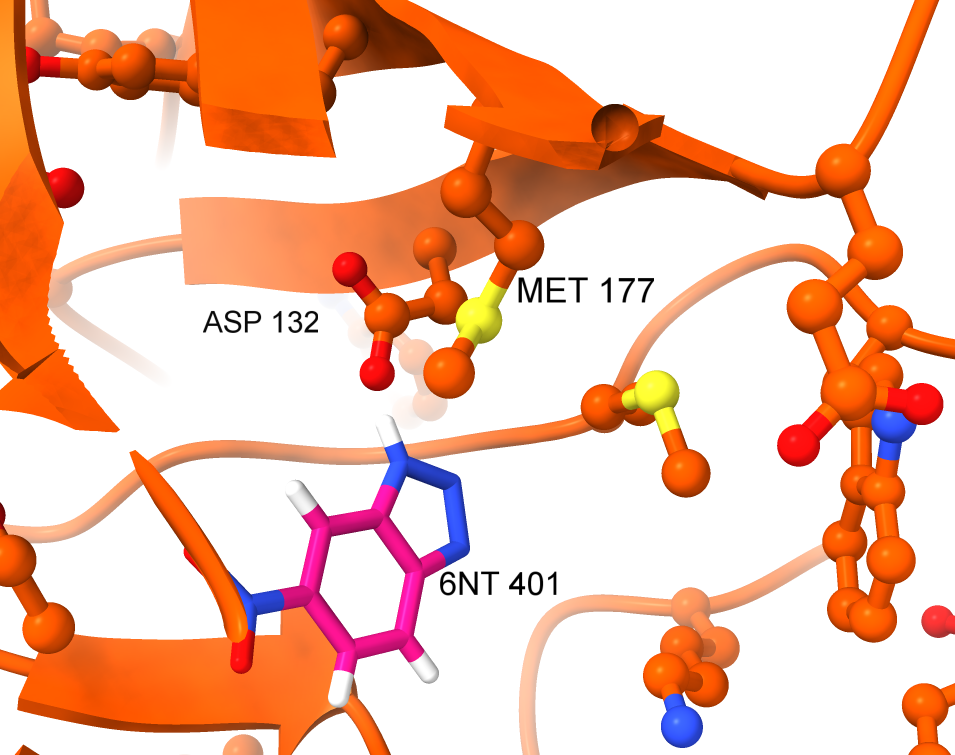

In [ ]:
from IPython.display import Image
Image(filename="/content/cluster_1_rep2.png")

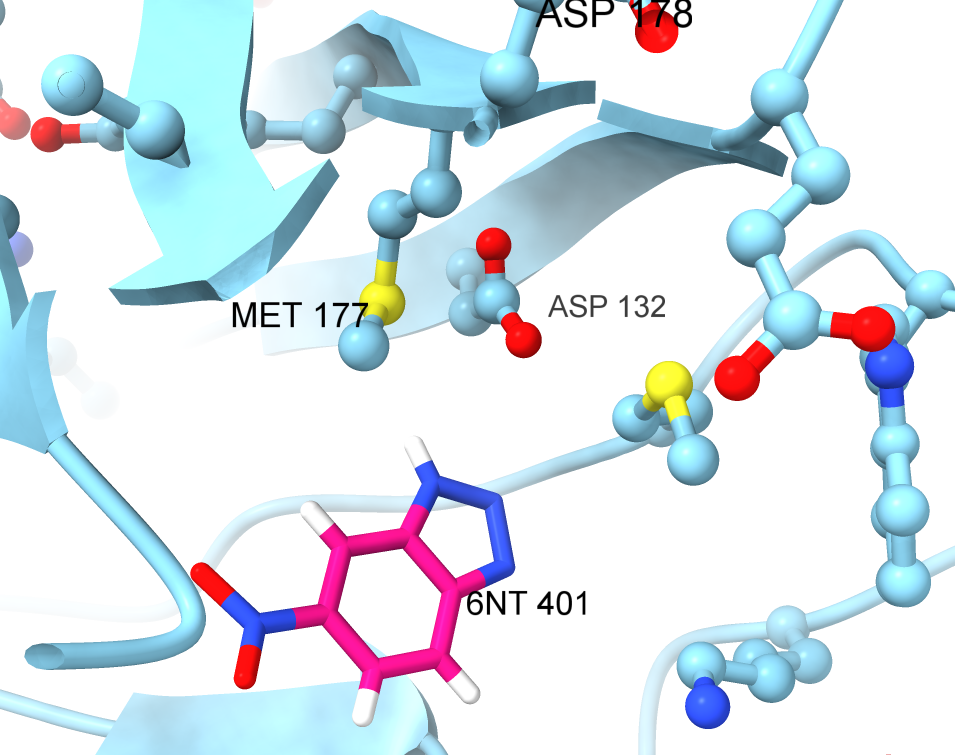

In [ ]:
Image(filename="/content/cluster_2_rep1.png")

## HG3.17 PLACER and Clustering

In [ ]:
%%writefile hg3.17_10_rotamer_ensemble.py

import sys, os
import warnings
warnings.filterwarnings("ignore")
import json
import pandas as pd
import matplotlib.pyplot as plt

from PLACER import PLACER
placer = PLACER.PLACER()

print("Trying to predict the ensemble strucutre of HG3 apo active site")

ciffile = "/content/7K4V_hg3.17_free.cif"
ODIR = "/content/75_hg3.17_placer_croped_final"

pl_inp = PLACER.PLACERinput()
pl_inp.cif(ciffile)
pl_inp.exclude_sm(True) #the function of this is to exclude the ligand during ensemble prediction (view https://github.com/baker-laboratory/PLACER/blob/main/modules/placer_input.py)
pl_inp.name(os.path.basename(ciffile).replace(".cif", ""))

pl_inp.crop_centers(points=[(7.150, 4.423, 9.580)]) #THIS IS REQUIRED!!!! , this is the MET172 coordinates from the RCSB CIF file

hg3_ensemble = placer.run(pl_inp, 75)

os.makedirs(ODIR, exist_ok=True)
print(f"Writing outputs to {ODIR}")
PLACER.protocol.dump_output(hg3_ensemble, f"{ODIR}/{pl_inp.name()}", rerank="prmsd")

df = pd.DataFrame.from_dict({k: [hg3_ensemble[n][k] for n in hg3_ensemble] for k in hg3_ensemble[0].keys() if k not in ["item", "model"]})


Overwriting hg3.17_10_rotamer_ensemble.py


In [ ]:
!mamba run -n placer_env python hg3.17_10_rotamer_ensemble.py

# device:  cuda:0
Using checkpoint: /content/PLACER/weights/PLACER_model_1.pt
# variables:  5071802
Trying to predict the ensemble strucutre of HG3 apo active site
Keeping these ligands fixed during prediction IF they are in the crop: [].
--> 0 7K4V_hg3.17_free {ID:type/atoms/bonds} : {A:polypeptide(L)/4657/4707; B:nonpoly/31/30}
model    1 :  fape= 1.98505  lddt= 0.91878  rmsd= 0.00000  kabsch= 0.00000  prmsd= 1.03589  plddt= 0.95415  plddt_pde= 0.91553  | time= 5.89s  mem= 3.13gb 
model    2 :  fape= 1.64643  lddt= 0.94624  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.96083  plddt= 0.96793  plddt_pde= 0.92478  | time= 4.01s  mem= 3.26gb 
model    3 :  fape= 1.88063  lddt= 0.92903  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.96299  plddt= 0.97258  plddt_pde= 0.92781  | time= 4.03s  mem= 3.26gb 
model    4 :  fape= 1.72755  lddt= 0.93477  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.95700  plddt= 0.96963  plddt_pde= 0.93122  | time= 4.14s  mem= 3.26gb 
model    5 :  fape= 1.94125  lddt= 0.92089  

We want to use MDAnalysis to convert the multimodal PDB file into a topology and trajectory file

In [ ]:
!pip install MDAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.4 MB/s eta 0:00:00


In [ ]:
import numpy as np

import MDAnalysis as mda
from MDAnalysis.analysis import pca, align

import warnings
# suppress some MDAnalysis warnings about writing PDB files
warnings.filterwarnings('ignore')

In [ ]:
pdb_file="/content/75_hg3.17_placer_croped_final_model.pdb"
ensemble=mda.Universe(pdb_file)

print(len(ensemble.trajectory[1]))

print(ensemble.trajectory)

u=ensemble

# 2. Extract and save the FIRST frame as your default PDB topology
topology_out = "hg3.17_croped_free_topology.pdb"
u.trajectory[0]  # Explicitly set the universe to the first frame
u.atoms.write(topology_out)
print(f"Saved the first frame as the topology file: {topology_out}")

# 3. Convert and write the entire ensemble into a .dcd trajectory file
trajectory_out = "hg3.17_croped_free_ensemble_trajectory.dcd"

# Open an MDAnalysis Writer for the .dcd format
with mda.Writer(trajectory_out, u.atoms.n_atoms) as W:
    # Loop through every frame in the loaded multi-model PDB
    for model in u.trajectory:
        W.write(u.atoms)

598
<PDBReader /content/75_hg3.17_placer_croped_final_model.pdb with 75 frames of 598 atoms>
Saved the first frame as the topology file: hg3.17_croped_free_topology.pdb


In [ ]:
%%writefile ensemble_hg3.17_free_cpptraj.in

parm /content/hg3.17_croped_free_topology.pdb
trajin /content/hg3.17_croped_free_ensemble_trajectory.dcd 1 last
cluster c1 \
  hieragglo epsilon 0.75 averagelinkage \
  rms :35,15,48,23,26,28&!@H= \
  out cnumvtime.dat \
  summary summary_hg3_apo_ensemble.dat \
  info info.dat \
  cpopvtime cpopvtime.agr normframe \
  repout rep repfmt pdb \
  singlerepout singlerep.nc singlerepfmt netcdf \
  avgout avg avgfmt pdb
run

Overwriting ensemble_hg3.17_free_cpptraj.in


In [ ]:
%%bash

source /usr/local/envs/ambert/amber.sh

#Note that this only works when all these are in the same cell. So I suppose when I run ambertools, I have reinitialize AMBERHOME env_varibale
echo "AMBERHOME is successfully set to: $AMBERHOME"

mkdir $AMBERHOME/ensemble_hg3.17_free_075A
cd $AMBERHOME/ensemble_hg3.17_free_075A

cpptraj -i /content/ensemble_hg3.17_free_cpptraj.in

AMBERHOME is successfully set to: /usr/local/envs/ambert

CPPTRAJ: Trajectory Analysis. V6.29.13 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 03/16/26 12:59:34
| Available memory: 3.718 GB

INPUT: Reading input from '/content/ensemble_hg3.17_free_cpptraj.in'
  [parm /content/hg3.17_croped_free_topology.pdb]
	Reading '/content/hg3.17_croped_free_topology.pdb' as PDB File
	Reading bond info from CONECT records.
	Not reading bond info from LINK records.
	Determining bond info from distances.
  [trajin /content/hg3.17_croped_free_ensemble_trajectory.dcd 1 last]
	Reading '/content/hg3.17_croped_free_ensemble_trajectory.dcd' as Charmm DCD
	NAMD unit cell detected.
  [cluster c1 hieragglo epsilon 0.75 averagelinkage rms :35,15,48,23,26,28&!@H= out cnumvtime.dat summary summary_hg3_apo_ensemble.dat info info.dat cpopvtime cpopvtime.agr normframe repout rep repfmt pdb singlerepout singlerep.nc singlerepfmt netcdf avgout avg avgfmt pdb]
	Using M

In [ ]:
download('ensemble_hg3.17_free_075A', '/usr/local/envs/ambert/ensemble_hg3.17_free_075A')

Successfully zipped /usr/local/envs/ambert/ensemble_hg3.17_free_075A into /content/ensemble_hg3.17_free_075A.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lets visualize the results. The blue represents the -ve control i.e HG3, while the ball and stick represented Asp is the +ve control, which is very well preorganized, as can be seen.

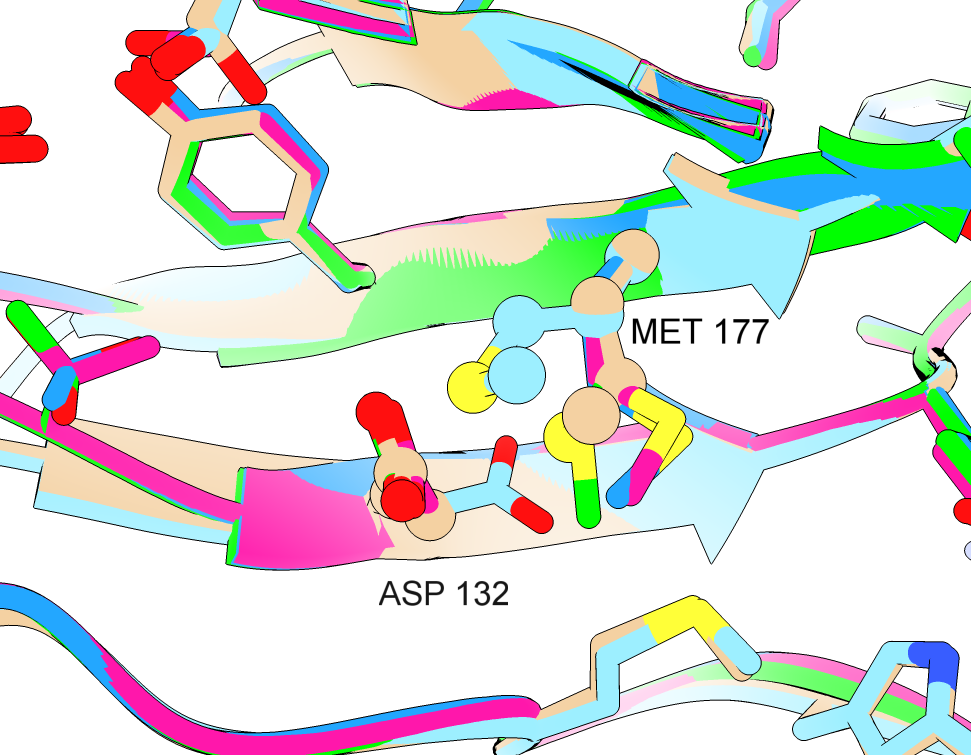

In [ ]:
Image(filename="/content/positive_vs_negative_control.png")

### Preorganization of RFD3 generated strucutre

In [ ]:
%%writefile rfd3_100_rotamer_bound_ligand.py

import sys, os
import warnings
warnings.filterwarnings("ignore")
import json
import pandas as pd
import matplotlib.pyplot as plt

from PLACER import PLACER
placer = PLACER.PLACER()

print("Trying to predict the ensemble strucutre of RFD3 active site (pls dont be preorganizaed")

ODIR = "/content/rfd3_100_rotamer_bound_ligand"
pdb_file='/content/config_scytalone_test5_0_model_0.pdb'
pl_inp = PLACER.PLACERinput()
#pl_inp.cif(ciffile)
pl_inp.pdb(pdb_file)
pl_inp.exclude_sm(True) #the function of this is to exclude the ligand during ensemble prediction (view https://github.com/baker-laboratory/PLACER/blob/main/modules/placer_input.py)
pl_inp.name(os.path.basename(pdb_file).replace(".pdb", ""))

pl_inp.crop_centers(points=[(0.102,1.078,-2.047)])

rfd3_test_ensemble = placer.run(pl_inp, 10) #we will keep it 10 for now just to understand if this is working

os.makedirs(ODIR, exist_ok=True)
print(f"Writing outputs to {ODIR}")
PLACER.protocol.dump_output(rfd3_test_ensemble, f"{ODIR}/{pl_inp.name()}", rerank="prmsd")

df = pd.DataFrame.from_dict({k: [rfd3_test_ensemble[n][k] for n in rfd3_test_ensemble] for k in rfd3_test_ensemble[0].keys() if k not in ["item", "model"]})


Overwriting rfd3_100_rotamer_bound_ligand.py


In [ ]:
!mamba run -n placer_env python rfd3_100_rotamer_bound_ligand.py

# device:  cuda:0
Using checkpoint: /content/PLACER/weights/PLACER_model_1.pt
# variables:  5071802
Trying to predict the ensemble strucutre of RFD3 active site (pls dont be preorganizaed
Keeping these ligands fixed during prediction IF they are in the crop: [].
--> 0 config_scytalone_test5_0_model_0 {ID:type/atoms/bonds} : {A:polypeptide(L)/2457/2476; B:nonpoly/14/15}
model    1 :  fape= 0.91004  lddt= 0.97582  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.57957  plddt= 0.98908  plddt_pde= 0.95312  | time= 5.33s  mem= 3.05gb 
model    2 :  fape= 0.84696  lddt= 0.97857  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.58639  plddt= 0.98815  plddt_pde= 0.94738  | time= 3.79s  mem= 3.18gb 
model    3 :  fape= 0.94191  lddt= 0.97381  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.57832  plddt= 0.98921  plddt_pde= 0.95277  | time= 3.90s  mem= 3.18gb 
model    4 :  fape= 1.03743  lddt= 0.96810  rmsd= 0.00000  kabsch= 0.00000  prmsd= 0.57733  plddt= 0.98962  plddt_pde= 0.95129  | time= 3.80s  mem= 3.18gb 
mode

Clustering analysis on the 100 ensemble structure

In [ ]:
!conda create --name ambert python=3.12

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/ambert

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    icu-78.2                   |       h33c6efd_0        12.1 MB  conda-forge
    ld_impl_linux-64-2.45.1    |default_hbd61a6d_101         709 KB  conda-forge
    libexpat-2.7.4             |       hecca717_0          75 KB  conda-forge
  

In [ ]:
!conda activate ambert
!conda config --add channels conda-forge
!conda config --set channel_priority strict
!conda install --name ambert dacase::ambertools-dac=25


CondaError: Run 'conda init' before 'conda activate'

Channels:
 - conda-forge
 - dacase
Platform: linux-64
Solving environment: \ | / - done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/ambert

  added / updated specs:
    - dacase::ambertools-dac=25


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ambertools-dac-25.3.0      |  py312h2009f2f_0       565.2 MB  dacase
    arpack-3.9.1               |nompi_hf03ea27_102         127 KB  conda-forge
    attr-2.5.2                 |       hb03c661_1          31 KB  conda-forge
    backports.zstd-1.3.0       |  py312h90b7ffd_0         232 KB  conda-forge
    blosc-1.21.6               |       he440d0b_1          47 KB  conda-forge


In [ ]:
!mamba install --name ambert -c conda-forge mdanalysis


Looking for: ['mdanalysis']

warning  libmamba Could not parse mod/etag header
warning  libmamba Could not parse mod/etag header
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64  10%
conda-forge/noarch    14%[+] 0.3s
conda-forge/linux-64  19%
conda-forge/noarch    31%[+] 0.4s
conda-forge/linux-64  25%
conda-forge/noarch    44%[+] 0.5s
conda-forge/linux-64  32%
conda-forge/noarch    58%[+] 0.6s
conda-forge/linux-64  37%
conda-forge/noarch    76%[+] 0.7s
conda-forge/linux-64  42%
conda-forge/noarch    79%[+] 0.8s
conda-forge/linux-64  44%
conda-forge/noarch    83%[+] 0.9s
conda-forge/linux-64  46%
conda-forge/noarch    85%[+] 1.0s
conda-forge/linux-64  49%
conda-forge/noarch    92%[+] 1.1s
conda-forge/linux-64  51%
conda-forge/noarch    98%conda-forge/noarch                                
[+] 1.2s
conda-forge/linux-64  53%[+] 1.3s
conda-forge/linux-64  65%[+] 1.4s
conda-forge/linux-64  68%[+] 1.5s
conda-forge/linux-64  68%[+] 1.6s
conda

In [ ]:
%cd /content

/content


In [ ]:
%%writefile trajectory_from_ensemble.py

import numpy as np

import MDAnalysis as mda
from MDAnalysis.analysis import pca, align

import warnings
# suppress some MDAnalysis warnings about writing PDB files
warnings.filterwarnings('ignore')

pdb_file="/content/rfd3_100_rotamer_bound_ligand/config_scytalone_test5_0_model_0_model.pdb"
ensemble=mda.Universe(pdb_file)

print(len(ensemble.trajectory[1]))

print(ensemble.trajectory)

u=ensemble

# 2. Extract and save the FIRST frame as your default PDB topology
topology_out = "rfd3_first_scytalone_topology.pdb"
u.trajectory[0]  # Explicitly set the universe to the first frame
u.atoms.write(topology_out)
print(f"Saved the first frame as the topology file: {topology_out}")

# 3. Convert and write the entire ensemble into a .dcd trajectory file
trajectory_out = "rfd3_first_scytalone_ensemble_trajectory.dcd"

# Open an MDAnalysis Writer for the .dcd format
with mda.Writer(trajectory_out, u.atoms.n_atoms) as W:
    # Loop through every frame in the loaded multi-model PDB
    for model in u.trajectory:
        W.write(u.atoms)

Writing trajectory_from_ensemble.py


In [ ]:
!mamba run -n ambert python trajectory_from_ensemble.py

585
<PDBReader /content/rfd3_100_rotamer_bound_ligand/config_scytalone_test5_0_model_0_model.pdb with 100 frames of 585 atoms>
Saved the first frame as the topology file: rfd3_first_scytalone_topology.pdb



Now we have to figure out what is the ID in cpptraj

In [ ]:
%%writefile cpptraj_index.py

import numpy as np

import MDAnalysis as mda
from MDAnalysis.analysis import pca, align

import warnings

ensemble=mda.Universe('/content/rfd3_100_rotamer_bound_ligand/config_scytalone_test5_0_model_0_model.pdb')

for i, residue in enumerate(ensemble.residues, start=1):
    print(f"cpptraj index: {i} | PDB Info: {residue}")

Writing cpptraj_index.py


In [ ]:
!mamba run -n ambert python cpptraj_index.py

cpptraj index: 1 | PDB Info: <Residue LEU, 18>
cpptraj index: 2 | PDB Info: <Residue THR, 22>
cpptraj index: 3 | PDB Info: <Residue PRO, 23>
cpptraj index: 4 | PDB Info: <Residue VAL, 24>
cpptraj index: 5 | PDB Info: <Residue SER, 25>
cpptraj index: 6 | PDB Info: <Residue LEU, 27>
cpptraj index: 7 | PDB Info: <Residue VAL, 28>
cpptraj index: 8 | PDB Info: <Residue ILE, 31>
cpptraj index: 9 | PDB Info: <Residue PHE, 49>
cpptraj index: 10 | PDB Info: <Residue LEU, 57>
cpptraj index: 11 | PDB Info: <Residue SER, 58>
cpptraj index: 12 | PDB Info: <Residue SER, 59>
cpptraj index: 13 | PDB Info: <Residue ALA, 60>
cpptraj index: 14 | PDB Info: <Residue GLN, 61>
cpptraj index: 15 | PDB Info: <Residue ILE, 62>
cpptraj index: 16 | PDB Info: <Residue LEU, 63>
cpptraj index: 17 | PDB Info: <Residue PHE, 67>
cpptraj index: 18 | PDB Info: <Residue SER, 85>
cpptraj index: 19 | PDB Info: <Residue ILE, 86>
cpptraj index: 20 | PDB Info: <Residue THR, 87>
cpptraj index: 21 | PDB Info: <Residue ALA, 88>
c

- HIS 120 --> 46
- ASP 119 --> 45
- LYS 97 --> 30

In [ ]:
%%writefile ensemble_rfd3_first_test_cpptraj.in

parm /content/rfd3_first_scytalone_topology.pdb
trajin /content/rfd3_first_scytalone_ensemble_trajectory.dcd 1 last
cluster c1 \
  hieragglo epsilon 0.75 averagelinkage \
  rms :46,45,30&!@H= \
  out cnumvtime.dat \
  summary summary_hg3_apo_ensemble.dat \
  info info.dat \
  cpopvtime cpopvtime.agr normframe \
  repout rep repfmt pdb \
  singlerepout singlerep.nc singlerepfmt netcdf \
  avgout avg avgfmt pdb
run

Overwriting ensemble_rfd3_first_test_cpptraj.in


In [ ]:
%%bash

source /usr/local/envs/ambert/amber.sh

#Note that this only works when all these are in the same cell. So I suppose when I run ambertools, I have reinitialize AMBERHOME env_varibale
echo "AMBERHOME is successfully set to: $AMBERHOME"

mkdir $AMBERHOME/rfd3_first_test_cpptraj_075A
cd $AMBERHOME/rfd3_first_test_cpptraj_075A

cpptraj -i /content/ensemble_rfd3_first_test_cpptraj.in

AMBERHOME is successfully set to: /usr/local/envs/ambert

CPPTRAJ: Trajectory Analysis. V6.29.13 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 03/18/26 05:11:39
| Available memory: 836.456 MB

INPUT: Reading input from '/content/ensemble_rfd3_first_test_cpptraj.in'
  [parm /content/rfd3_first_scytalone_topology.pdb]
	Reading '/content/rfd3_first_scytalone_topology.pdb' as PDB File
	Reading bond info from CONECT records.
	Not reading bond info from LINK records.
	Determining bond info from distances.
  [trajin /content/rfd3_first_scytalone_ensemble_trajectory.dcd 1 last]
	Reading '/content/rfd3_first_scytalone_ensemble_trajectory.dcd' as Charmm DCD
	NAMD unit cell detected.
  [cluster c1 hieragglo epsilon 0.75 averagelinkage rms :46,45,30&!@H= out cnumvtime.dat summary summary_hg3_apo_ensemble.dat info info.dat cpopvtime cpopvtime.agr normframe repout rep repfmt pdb singlerepout singlerep.nc singlerepfmt netcdf avgout avg avgfmt pdb]
	Us

mkdir: cannot create directory ‘/usr/local/envs/ambert/rfd3_first_test_cpptraj_075A’: File exists


In [ ]:
download('rfd3_first_test_cpptraj_075A', '/usr/local/envs/ambert/rfd3_first_test_cpptraj_075A')

Successfully zipped /usr/local/envs/ambert/rfd3_first_test_cpptraj_075A into /content/rfd3_first_test_cpptraj_075A.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>